In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 2019.csv to 2019.csv


Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')
기울기: 2.218
절편: 3.399
회귀식: 행복지수 = 2.218 × GDP + 3.399
결정계수(R²): 0.6303


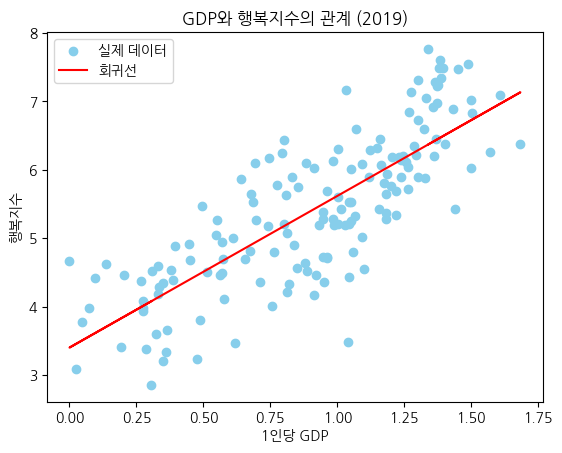

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv('2019.csv', encoding='UTF-8')

print(df.columns)

df = df[['Country or region', 'Score', 'GDP per capita']]
df.columns = ['Country', 'Happiness', 'GDP']

df = df.dropna()

X = df[['GDP']]
y = df['Happiness']

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(f"기울기: {slope:.3f}")
print(f"절편: {intercept:.3f}")
print(f"회귀식: 행복지수 = {slope:.3f} × GDP + {intercept:.3f}")

r2 = model.score(X, y)
print(f"결정계수(R²): {r2:.4f}")

plt.scatter(X, y, color='skyblue', label='실제 데이터')
plt.plot(X, model.predict(X), color='red', label='회귀선')
plt.xlabel('1인당 GDP')
plt.ylabel('행복지수')
plt.title('GDP와 행복지수의 관계 (2019)')
plt.legend()
plt.show()
